# Example measurement system's flow without information quality


The code illustrates a typical flow of information -- starting with the export of raw data and ending with a simple indicator. 

## Part 1: configuration

In [16]:
import requests
import os.path
import math
import time
import datetime
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import warnings
warnings.filterwarnings("ignore")

In [17]:
#####################################
# Configuration
#####################################
HISTORY_DAYS = 21                # Days of data to download
PREDICT_DAYS = 21

# Data sources
# This should work for any Bugzilla server, just change the URL and pick a (case-sensitive) "product" from their data.
# Have a look here for more ideas: https://www.bugzilla.org/installation-list/
BUGZILLA={"url": "https://bugs.webkit.org", "product": "WebKit"}
#BUGZILLA={"url": "https://gcc.gnu.org/bugzilla", "product": "gcc"}
#BUGZILLA={"url": "https://bugzilla.mozilla.org", "product": "Firefox"}

## Part 2: export from the database

In [18]:
#####################################
# Data Extraction, Storage and Access
#####################################
# RAW_DATA is a pandas dataframe representing a complete table of the data, one row per reported defect.

# Download up-to-date data to local filesystem
def download_csv(filename, bugzilla_url, product, days):
    data_url=bugzilla_url + "/buglist.cgi"
    data_params = {
        #"product": "WebKit",
        "product": product,
        "query_format": "advanced",
        "bug_status": [ "NEW", "ASSIGNED", "REOPENED", "RESOLVED", "CLOSED" ],
        "x_axis_field": "resolution",
        "y_axis_field": "assigned_to",
        "ctype": "csv",
        #"chfield": [ "resolution", "bug_status", "[Bug creation]" ],
        "columnlist": "bug_id,product,component,assigned_to,bug_status,resolution,opendate,changeddate",
        "chfieldto": "Now",
        "chfieldfrom": "-{}d".format(days)
    }
    print("Downloading fresh data to {}".format(filename))
    r = requests.get(data_url, params=data_params)
    with open(filename, "w") as f:
        f.write(r.text)

# Returns a pandas dataframe of the raw source data
def get_data(bugzilla_url, product, days):
    filename = "data_{}_{}.csv".format(product,days)
    download_csv(filename, bugzilla_url, product, days)
    print('Data download complete')
    df = pd.read_csv(filename, header=0, parse_dates=["opendate", "changeddate"])
    return df
    

RAW_DATA = get_data(BUGZILLA["url"], BUGZILLA["product"], HISTORY_DAYS)


Data download complete


## Part 3: base measures


In [19]:
#################################################
# Measurement Methods (generating base measures)
#################################################

# Returns a dataframe. The actual measure is the number of data elements in the dataframe.
base_new      = lambda df,ldate,udate: df[  (df["opendate"] >= ldate)
                                        &   (df["opendate"] < udate)
                                         ]

base_resolved = lambda df,ldate,udate: df[  (df["changeddate"] >= ldate)
                                        &   (df["changeddate"] < udate)
                                        #&   (df["assigned_to"] != 'webkit-unassigned')
                                        #&   (df["assigned_to"] != "commit-queue")
                                        &   (df["bug_status"] == 'RESOLVED')
                                         ]
                                         
def count(df):
    return len(df.index)

def daily_series(df, method):
    global HISTORY_DAYS
    y = []
    x = []
    for day in range(HISTORY_DAYS):
        startdate = pd.Timestamp(datetime.date.today() - datetime.timedelta(days=(day+1)))
        enddate = pd.Timestamp(datetime.date.today() - datetime.timedelta(days=day))
        y = [ count(method(df,startdate, enddate)) ] + y
        x = [ -day ] + x
    return x,y

In [20]:
print("A random sample of the raw data:")
RAW_DATA.sample(5)

A random sample of the raw data:


,bug_id,product,component,assigned_to,bug_status,resolution,opendate,changeddate
595,207935,WebKit,Tools / Tests,aakash_jain,ASSIGNED,---,2020-02-19 07:38:10,2020-02-19 07:41:55
338,207461,WebKit,New Bugs,webkit-unassigned,NEW,---,2020-02-10 07:57:16,2020-02-10 08:03:19
1012,207819,WebKit,Web Inspector,nvasilyev,RESOLVED,FIXED,2020-02-15 17:37:33,2020-02-17 16:26:57
995,207963,WebKit,New Bugs,megan_gardner,RESOLVED,FIXED,2020-02-19 14:30:20,2020-02-20 15:16:36
1262,207930,WebKit,Platform,webkit-unassigned,RESOLVED,FIXED,2020-02-19 01:26:18,2020-02-20 12:07:17


In [21]:
print("A random sample of the base_new metric:")
now = pd.Timestamp(datetime.date.today())
last_week=pd.Timestamp(datetime.date.today() - datetime.timedelta(days=7))
base_new(RAW_DATA, last_week, now).sample(5)

A random sample of the base_new metric:


,bug_id,product,component,assigned_to,bug_status,resolution,opendate,changeddate
596,208003,WebKit,Tools / Tests,aakash_jain,ASSIGNED,---,2020-02-20 07:02:50,2020-02-20 13:05:46
479,207927,WebKit,WebKitGTK,webkit-unassigned,NEW,---,2020-02-18 20:03:34,2020-02-18 20:03:34
1440,208055,WebKit,Frames,zalan,RESOLVED,FIXED,2020-02-21 07:49:37,2020-02-24 16:40:20
995,207963,WebKit,New Bugs,megan_gardner,RESOLVED,FIXED,2020-02-19 14:30:20,2020-02-20 15:16:36
1267,208002,WebKit,WPE WebKit,webkit-unassigned,RESOLVED,FIXED,2020-02-20 05:10:40,2020-02-21 03:05:43


In [22]:
###################################
# Base Measures (as daily series)
###################################

dnx, daily_new = daily_series(RAW_DATA, base_new)

drx, daily_resolved = daily_series(RAW_DATA, base_resolved)

Visualization of the base measure trend


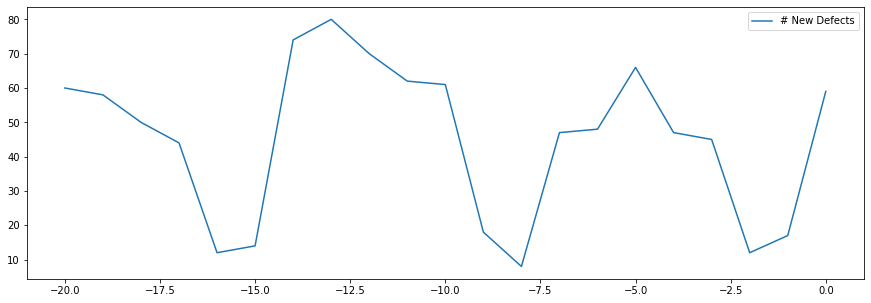

In [23]:
print("Visualization of the base measure trend")
plt.plot(dnx, daily_new, label="# New Defects")
plt.gcf().set_size_inches(15,5)
_=plt.legend()

## Part 4: Derived measures

In [24]:
#########################################
# Measurement Functions (generating derived measures from base measures)
#########################################

der_assigned_developers = lambda daily_developers: int(np.sum(daily_developers[-1:-8:-1]) / 7)

der_resolved_per_devday = lambda daily_resolved: np.sum(daily_resolved) / np.average(daily_resolved)

def der_predicted_defects(daily_new, predict_days, show=False):
    # 0 is first day after history, 6 is last day of history, etc.
    idx_by_weekday = [None]*7
    hist_by_weekday = [None]*7
    function_by_weekday = [None]*7
    pred_by_weekday = [None]*7
    n_predictions_per_weekday = int(math.ceil(predict_days / 7))
    for wd in range(7):
        start_sample = len(daily_new) - (7 - wd)
        # All the mondays, from oldest to newest
        hist_by_weekday[wd] = list(reversed(daily_new[start_sample:0:-7]))
        idx_by_weekday[wd] = range(-len(hist_by_weekday[wd]),0)
        
        # Find a 3rd degree polynomial that fits this progression
        function_by_weekday[wd] = np.polyfit(idx_by_weekday[wd], hist_by_weekday[wd], deg=3)
        
        # Predict the number of new defects for future mondays
        idx_pred = list(range(0, n_predictions_per_weekday))
        pred_by_weekday[wd] = np.polyval(function_by_weekday[wd], idx_pred)        

    # Interlace the weekday predictions into a sequence of days
    pred_x = list(range(predict_days))
    pred_y = [0] * predict_days
    for i in range(predict_days):
        wd = i % 7
        wdi = int(i / 7)
        pred_y[i] = max(pred_by_weekday[wd][wdi], 0)
    
    # Show the curve-fitting and prediction for one of the weekdays
    if show:
        wd=4
        idx_hist = idx_by_weekday[wd]
        idx_pred = range(-len(hist_by_weekday[wd]),0 + int(predict_days / 7))
        poly = np.polyval(function_by_weekday[wd], idx_pred)
        plt.plot(idx_hist, hist_by_weekday[wd], label="Historic data")
        plt.plot(idx_pred, poly, label="Polynomial prediction")
        plt.legend()
        
    return pred_x,pred_y
    

Predicted new defects for one weekday:


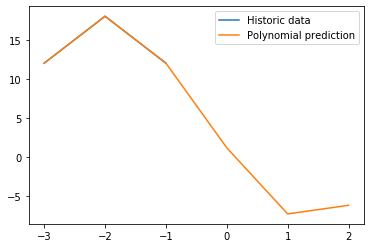

In [25]:
print("Predicted new defects for one weekday:")
_=der_predicted_defects(daily_new, PREDICT_DAYS, show=True)

In [26]:
###################################
# Derived Measures
###################################
pnew_x,pnew_y = der_predicted_defects(daily_new, PREDICT_DAYS, show=False)

defs_per_devday = der_resolved_per_devday(daily_resolved)

Predicted new defects for 21 days into the future: 626


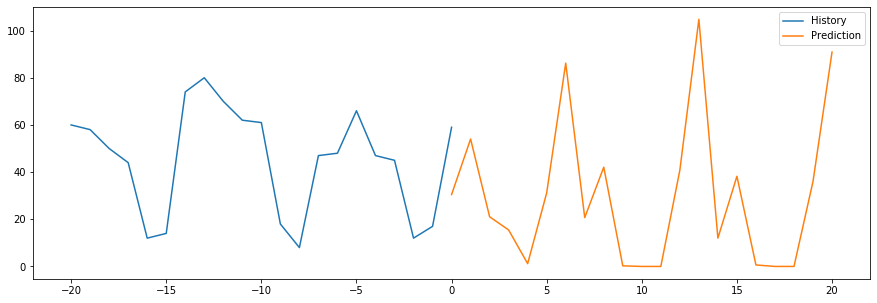

In [27]:
print(f'Predicted new defects for {PREDICT_DAYS} days into the future: {np.sum(pnew_y):.0f}')
plt.plot(dnx, daily_new, label="History")
plt.plot(pnew_x, pnew_y, label="Prediction")
plt.gcf().set_size_inches(15,5)
_=plt.legend()

## Part 5: Indicators

In [28]:
###################################
# Analysis Models (indicators from derived measures)
###################################

# Returns (devs_needed,indicator)
# indictator is 'green', 'yellow' or 'red'
def ind_inflow_ok(expected_defects, defs_per_devday):
    average_inflow = np.sum(expected_defects) / PREDICT_DAYS
    indicator = 0
    if ( average_inflow > 10):
        indicator = 'red'
    elif ( average_inflow < 5):
        indicator = 'green'
    else:
        indicator = 'yellow'
    return (average_inflow,indicator)

In [29]:
###################################
# Indicators
################################### 

expected_need,indicator_color = ind_inflow_ok(pnew_y, defs_per_devday)

Expected average of 30 defects per day in the next 21 days.


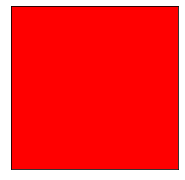

In [30]:
print(f'Expected average of {expected_need:.0f} defects per day in the next {PREDICT_DAYS} days.')
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3,3))
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
ax.set_facecolor(indicator_color)
